# Step 3 — SpatioType assignment on TCGA

Hierarchically clusters TCGA-BRCA patients on their 11-cluster composition vectors,
picks the number of SpatioTypes by the within-cluster sum of squares (elbow) plus the
Davies–Bouldin index, and validates the resulting groups against disease-free survival.

The clustering parameters, validity-metric code, palette and row-order
live in `../lib/clustering_helpers.py`.

**Inputs (committed under `clustering/data/`)**
- `cluster_props_TCGA.csv` — one row per TCGA patient; 11 columns of `Cluster N` proportions plus survival fields.

**Outputs (committed under `clustering/data/`)**
- `cluster_validity_metrics.csv` — k versus WSS and Davies–Bouldin.
- `spatiotypes_TCGA_k5.csv` — input data plus assigned `Metacluster` (1…5) and `SpatioType` columns.

The five SpatioType labels follow the paper: **Proliferation-Enriched**,
**Immune-Modulated**, **Immune-Inactive**, **Lipid-Metabolic**, **Hedgehog-Active**.
The last two have only 5 and 11 patients respectively and are kept in the heatmap
for completeness but excluded from the survival comparison.

## Setup

In [1]:
import sys
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

from clustering_helpers import (
    compute_validity_metrics, assign_spatiotypes, scale_features,
    SPATIOTYPE_PALETTE, HEATMAP_ROW_ORDER, SPATIOTYPE_LEVELS,
)

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load patient × cluster composition

In [2]:
df = pd.read_csv("../data/cluster_props_TCGA.csv", index_col=0)
cluster_cols = [f"Cluster {i}" for i in range(1, 12)]
X = scale_features(df[cluster_cols].values)
df.shape, X.shape

((858, 30), (858, 11))

## Choose k

Davies–Bouldin index versus k. Lower is better. Computed in `compute_validity_metrics()` using a Ward linkage on the standardised composition matrix.

In [3]:
metrics = compute_validity_metrics(X, ks=range(1, 11))
metrics.to_csv("../data/cluster_validity_metrics.csv", index=False)
metrics

,k,WSS,DB
0,1,9438.000000,NaN
1,2,8413.862528,1.368169
2,3,7477.082919,1.829906
3,4,6606.932173,1.308240
4,5,5784.331313,1.074622
5,6,5014.450678,1.215901
6,7,4418.296134,1.100699
7,8,3869.596478,1.059661
8,9,3355.380443,1.009144
9,10,2844.770050,0.964597


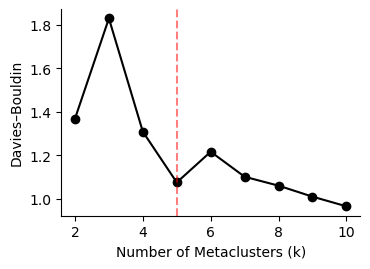

In [4]:
m_db = metrics.dropna(subset=["DB"])

fig, ax = plt.subplots(figsize=(3.8, 2.8))
ax.plot(m_db["k"], m_db["DB"], marker="o", color="black")
ax.axvline(5, color="red", linestyle="--", alpha=0.5)
ax.set(xlabel="Number of Metaclusters (k)", ylabel="Davies–Bouldin")
plt.tight_layout()
plt.show()

**Choice: k = 5.** Davies–Bouldin reaches its first local minimum at k=5. Two of the five Metaclusters end up with only 5 and 11 patients and are too small for the survival comparison.

## Assign SpatioTypes

In [5]:
sp = assign_spatiotypes(X)
df = df.assign(Metacluster_k5=sp["Metacluster"].values,
               SpatioType=sp["SpatioType"].values)
df["SpatioType"].value_counts().reindex(SPATIOTYPE_LEVELS)

SpatioType
Proliferation-Enriched    218
Immune-Modulated          562
Immune-Inactive            62
Lipid-Metabolic             5
Hedgehog-Active            11
Name: count, dtype: int64

In [6]:
out = df[["tissue_submitter_id"] + cluster_cols + ["DFI", "DFI.time", "OS", "OS.time", "Metacluster_k5", "SpatioType"]]
out.to_csv("../data/spatiotypes_TCGA_k5.csv")
out.head()

,tissue_submitter_id,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,DFI,DFI.time,OS,OS.time,Metacluster_k5,SpatioType
TCGA-3C-AALI-01,TCGA-3C-AALI-01,0.606562,0.000000,0.0,0.000000,0.031638,0.076303,0.000000,0.114846,0.000000,0.170652,0.0,0,133.500000,0,4005,3,Immune-Modulated
TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,0.053905,0.511493,0.0,0.025371,0.000000,0.000000,0.000000,0.138740,0.000000,0.270491,0.0,0,49.133333,0,1474,5,Proliferation-Enriched
TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,11.600000,0,348,3,Immune-Modulated
TCGA-A1-A0SB-01,TCGA-A1-A0SB-01,0.000000,0.000000,0.0,0.313685,0.080537,0.000000,0.065071,0.240152,0.300554,0.000000,0.0,0,8.633333,0,259,5,Proliferation-Enriched
TCGA-A1-A0SD-01,TCGA-A1-A0SD-01,0.000000,0.770007,0.0,0.084580,0.076773,0.013988,0.000000,0.054652,0.000000,0.000000,0.0,0,14.566667,0,437,5,Proliferation-Enriched


## Heatmap of cluster proportions

Rows = the 11 ST clusters in the order used in the paper. Columns = patients,
ordered by the Ward dendrogram and split into the five SpatioType blocks. The
bottom annotation bar colours each patient by their SpatioType using the
JAMA palette.

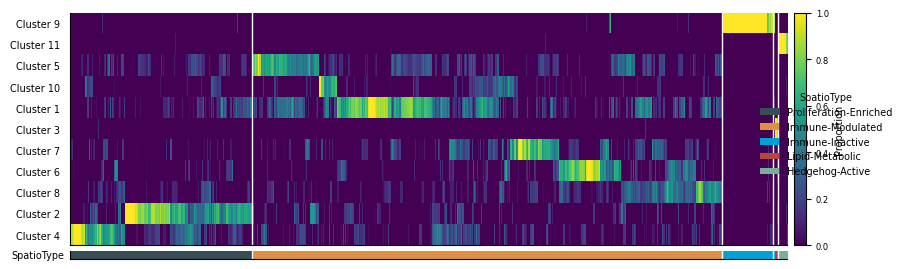

In [7]:
from scipy.cluster.hierarchy import linkage, leaves_list

Z = linkage(X, method="ward")
order_full = leaves_list(Z)

# Build the values matrix, rows ordered as in the paper.
mat = df.loc[df.index[order_full], HEATMAP_ROW_ORDER].T.values  # 11 × n_patients
col_st = df["SpatioType"].values[order_full]

# Sub-order within each SpatioType block to keep blocks contiguous,
# preserving the dendrogram order inside each block.
block_idx = []
for level in SPATIOTYPE_LEVELS:
    block_idx.extend([i for i, st in enumerate(col_st) if st == level])
mat = mat[:, block_idx]
col_st = col_st[block_idx]

# Determine block boundaries for the vertical separators.
boundaries = []
prev = col_st[0]
for i, st in enumerate(col_st):
    if st != prev:
        boundaries.append(i)
        prev = st

fig = plt.figure(figsize=(9.5, 3.2))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    width_ratios=[60, 1], height_ratios=[30, 1],
    hspace=0.05, wspace=0.02,
)

ax_h = fig.add_subplot(gs[0, 0])
im = ax_h.imshow(mat, aspect="auto", cmap="viridis", interpolation="nearest", vmin=0, vmax=1)
for b in boundaries:
    ax_h.axvline(b - 0.5, color="white", linewidth=1.0)
ax_h.set_yticks(range(len(HEATMAP_ROW_ORDER)))
ax_h.set_yticklabels(HEATMAP_ROW_ORDER, fontsize=7)
ax_h.set_xticks([])
ax_h.tick_params(left=False)

# colour bar
ax_cb = fig.add_subplot(gs[0, 1])
plt.colorbar(im, cax=ax_cb).set_label("Proportion", fontsize=7)
ax_cb.tick_params(labelsize=6)

# SpatioType annotation bar
ax_a = fig.add_subplot(gs[1, 0], sharex=ax_h)
rgb = np.array([list(mcolors.to_rgb(SPATIOTYPE_PALETTE[s])) for s in col_st])[None, :, :]
ax_a.imshow(rgb, aspect="auto", interpolation="nearest")
ax_a.set_xticks([]); ax_a.set_yticks([])
ax_a.set_ylabel("SpatioType", rotation=0, ha="right", va="center", fontsize=7)
for b in boundaries:
    ax_a.axvline(b - 0.5, color="white", linewidth=1.0)

# legend
handles = [mpatches.Patch(facecolor=SPATIOTYPE_PALETTE[s], label=s) for s in SPATIOTYPE_LEVELS]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(1.0, 0.5),
           fontsize=7, frameon=False, title="SpatioType", title_fontsize=7)

plt.show()

## Disease-free survival by SpatioType (3 main groups)

The two small SpatioTypes (Lipid-Metabolic, n=5; Hedgehog-Active, n=11) are excluded
from the survival comparison since their sample sizes are insufficient for stable
Kaplan–Meier estimation.

Legend is placed outside the plot.

In [8]:
main_levels = ["Proliferation-Enriched", "Immune-Modulated", "Immune-Inactive"]

main = df[df["SpatioType"].isin(main_levels)].copy()
main = main.dropna(subset=["DFI", "DFI.time"])
main["DFI"] = main["DFI"].astype(float)
main["DFI.time"] = main["DFI.time"].astype(float)
main["SpatioType"].value_counts().reindex(main_levels)

SpatioType
Proliferation-Enriched    218
Immune-Modulated          562
Immune-Inactive            62
Name: count, dtype: int64

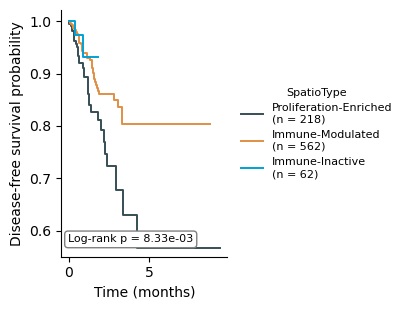

In [9]:
fig, ax = plt.subplots(figsize=(4.2, 3.2))

for st in main_levels:
    g = main[main["SpatioType"] == st]
    KaplanMeierFitter().fit(
        durations=g["DFI.time"] / 30.44, event_observed=g["DFI"],
        label=f"{st}\n(n = {len(g)})",
    ).plot_survival_function(
        ax=ax, color=SPATIOTYPE_PALETTE[st], linewidth=1.4, ci_show=False,
    )

p = multivariate_logrank_test(main["DFI.time"], main["SpatioType"], main["DFI"]).p_value
ax.text(0.04, 0.05, f"Log-rank p = {p:.2e}", transform=ax.transAxes,
        fontsize=8, va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

ax.set(xlabel="Time (months)",
       ylabel="Disease-free survival probability",
       title="")
ax.set_ylim(bottom=max(0.55, ax.get_ylim()[0]))
ax.legend(
    title="SpatioType",
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    fontsize=8, title_fontsize=8, frameon=False,
)
plt.tight_layout()
plt.show()

In [10]:
pairwise = pairwise_logrank_test(main["DFI.time"], main["SpatioType"], main["DFI"])
pairwise.summary

test_statistic         p  -log2(p)
Immune-Inactive  Immune-Modulated              0.075727  0.783173  0.352596
                 Proliferation-Enriched        1.453609  0.227950  2.133212
Immune-Modulated Proliferation-Enriched        9.073103  0.002594  8.590625